In [1]:
import globals as gl
import pickle

import os
import numpy as np
import sys

import PcmPy as pcm

import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches

sys.path.append('/Users/mnlmrc/Documents/GitHub')
sys.path.append('/Users/mnlmrc/Documents/GitHub/Functional_Fusion')
sys.path.append('/home/ROBARTS/memanue5/Documents/GitHub')
sys.path.append('/home/ROBARTS/memanue5/Documents/GitHub/Functional_Fusion')

import rsatoolbox as rsa

import warnings
warnings.filterwarnings("ignore")

plt.close('all')
plt.style.use('default')


Base directory found: /Volumes/diedrichsen_data$/data/SensoriMotorPrediction/
Base directory: /Volumes/diedrichsen_data$/data/SensoriMotorPrediction/


loading subj102
loading subj103
loading subj104
loading subj106
loading subj107


Text(0.5, 1.0, 'Reaction time')

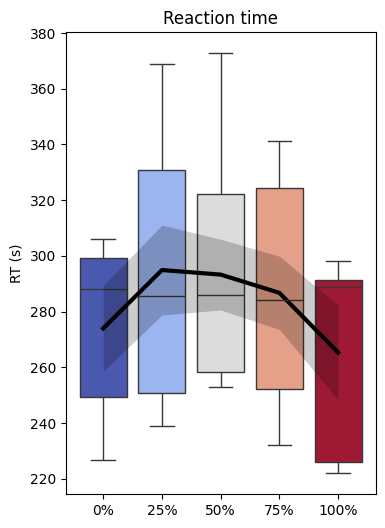

In [2]:
snS = [102, 103, 104, 106, 107]
experiment = 'smp2'

df = pd.DataFrame()
for sn in snS:
    print(f'loading subj{sn}')
    df_tmp = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}_force_single_trial.tsv'), sep='\t')
    df_tmp['sn'] = sn
    df = pd.concat([df,df_tmp ])

df = df.groupby(['stimFinger', 'cue', 'GoNogo','sn']).mean(numeric_only=True).reset_index()
df['cue'] = df['cue'].map(gl.cue_mapping)
df['stimFinger'] = df['stimFinger'].map(gl.stimFinger_mapping)

fig, axs = plt.subplots(figsize=(4, 6))

sns.boxplot(data=df[df['GoNogo'] == 'go'], x='cue', y='RT', order=gl.cues, palette=list(gl.colour_mapping.values())[:5])
sns.lineplot(data=df[df['GoNogo'] == 'go'], x='cue', y='RT', color='k', err_kws={'lw': 0, 'zorder': 1e6}, errorbar='se', markers=True, lw=3)

axs.set_ylabel('RT (s)')
axs.set_xlabel('')

axs.set_title('Reaction time')

Text(0.5, 0.98, 'Reaction time')

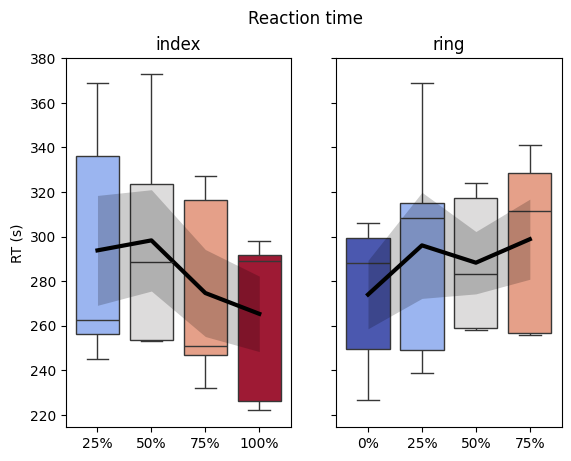

In [3]:
fig, axs = plt.subplots(1, 2, sharey=True)

sns.boxplot(
    ax = axs[0],
    data=df[(df['GoNogo'] == 'go') & (df['stimFinger'] == 'index')],
    x='cue',
    y='RT',
    order=gl.cues,
    palette=list(gl.colour_mapping.values())[:5]
)

sns.boxplot(
    ax = axs[1],
    data=df[(df['GoNogo'] == 'go') & (df['stimFinger'] == 'ring')],
    x='cue',
    y='RT',
    order=gl.cues,
    palette=list(gl.colour_mapping.values())[:5]
)

sns.lineplot(ax=axs[0], data=df[(df['GoNogo'] == 'go') & (df['stimFinger'] == 'index')], x='cue', y='RT', color='k', err_kws={'lw': 0, 'zorder': 1e6}, errorbar='se', markers=True, lw=3)
sns.lineplot(ax=axs[1], data=df[(df['GoNogo'] == 'go') & (df['stimFinger'] == 'ring')], x='cue', y='RT', color='k', err_kws={'lw': 0, 'zorder': 1e6}, errorbar='se', markers=True, lw=3)

axs[0].set_ylabel('RT (s)')
axs[0].set_xlabel('')
axs[1].set_xlabel('')

axs[0].set_title('index')
axs[1].set_title('ring')

fig.suptitle('Reaction time')

Text(0.5, 0.01, 'time relative to perturbation onset (s)')

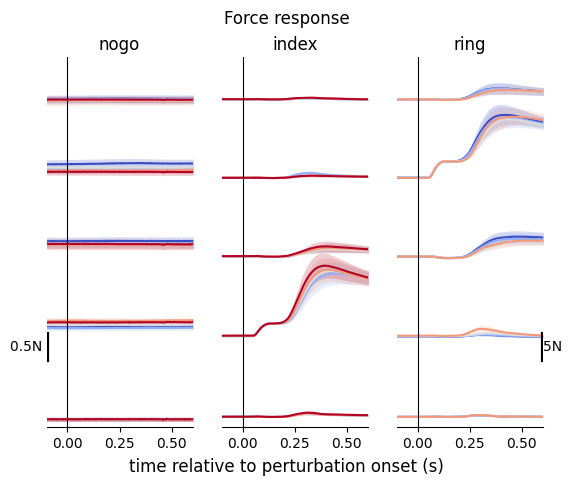

In [2]:
from myplot import make_yref

experiment = 'smp2'

npz = np.load(os.path.join(gl.baseDir, experiment, 'force.segmented.avg.npz'), allow_pickle=True)
force = npz['data_array']
descr = pd.DataFrame(npz['descriptor'].item())

fig, axs = plt.subplots(ncols=3, sharex=True,)

vsep_go = 15
vsep_nogo = 1.5

tAx = np.linspace(-gl.prestim, gl.poststim, force.shape[-1])

for c, cue in enumerate(descr.cue.unique()):
    for sf, stimF in enumerate(descr.stimFinger.unique()):
        axs[sf].set_title(stimF)
        for f, finger in enumerate(descr.finger.unique()):
            force_avg = force[(descr.cue == cue) & (descr.stimFinger == stimF) & (descr.GoNogo == 'go') & (descr.finger == finger)].mean(axis=0, keepdims=True).squeeze()
            force_err = force[(descr.cue == cue) & (descr.stimFinger == stimF) & (descr.GoNogo == 'go') & (descr.finger == finger)].std(axis=0, keepdims=True).squeeze() / np.sqrt(len(descr.sn.unique()))
            axs[sf].plot(tAx, force_avg + f * vsep_go, color=list(gl.colour_mapping.values())[c])
            axs[sf].fill_between(tAx, force_avg + f * vsep_go - force_err, force_avg + f * vsep_go + force_err, color=list(gl.colour_mapping.values())[c], lw=0, alpha=.2)

for c, cue in enumerate(descr.cue.unique()):
    for sf, stimF in enumerate(descr.stimFinger.unique()):
        for f, finger in enumerate(descr.finger.unique()):
            force_avg = force[(descr.cue == cue) & (descr.stimFinger == stimF) & (descr.GoNogo == 'nogo') & (descr.finger == finger)].mean(axis=0, keepdims=True).squeeze()
            force_err = force[(descr.cue == cue) & (descr.stimFinger == stimF) & (descr.GoNogo == 'nogo') & (descr.finger == finger)].std(axis=0, keepdims=True).squeeze() / np.sqrt(len(descr.sn.unique()))
            axs[0].plot(tAx, force_avg + f * vsep_nogo, color=list(gl.colour_mapping.values())[c])
            axs[0].fill_between(tAx, force_avg + f * vsep_nogo - force_err, force_avg + f * vsep_nogo + force_err, color=list(gl.colour_mapping.values())[c], lw=0, alpha=.2)

for ax in axs:
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.axvline(0, ls='-', color='k', lw=.8)
    ax.set_yticks([])

axs[0].set_xlim([-.1, .6])
axs[0].set_ylim([-.21, 6.90])
axs[1].set_ylim([-2, 68])
axs[2].set_ylim([-2, 68])

make_yref(axs[2], reference_length=5, pos='right')
make_yref(axs[0], reference_length=.5, pos='left')

fig.suptitle('Force response')
fig.supxlabel('time relative to perturbation onset (s)')

loading subj102
loading subj103
loading subj104
loading subj106
loading subj107


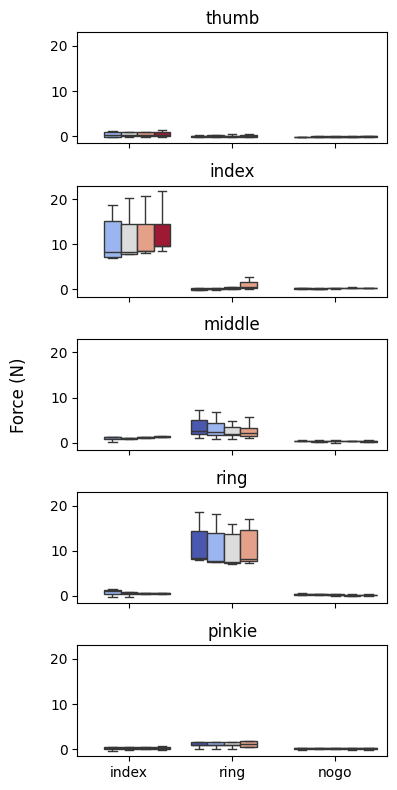

In [22]:
snS = [102, 103, 104, 106, 107]
experiment = 'smp2'

df = pd.DataFrame()
for sn in snS:
    print(f'loading subj{sn}')
    df_tmp = pd.read_csv(os.path.join(gl.baseDir, experiment, gl.behavDir, f'subj{sn}', f'{experiment}_{sn}_force_single_trial.tsv'), sep='\t')
    df_tmp['sn'] = sn
    df = pd.concat([df,df_tmp ])

df = df.groupby(['stimFinger', 'cue', 'GoNogo','sn']).mean(numeric_only=True).reset_index()
df['cue'] = df['cue'].map(gl.cue_mapping)
df['stimFinger'] = df['stimFinger'].map(gl.stimFinger_mapping)
    
fig, axs = plt.subplots(nrows=5, sharex=True, sharey=True, figsize=(4, 8))
    

for f, finger in enumerate(gl.channels['mov']):

    sns.boxplot(x='stimFinger', y=finger, ax=axs[f], hue='cue', data=df,  showfliers=False,  legend=False, hue_order=gl.cues, palette=list(gl.colour_mapping.values())[:5])
    
    axs[f].set_xlabel('')
    axs[f].set_ylabel('')
    axs[f].set_title(finger)

fig.supylabel('Force (N)')
fig.tight_layout()

NameError: name 'L' is not defined

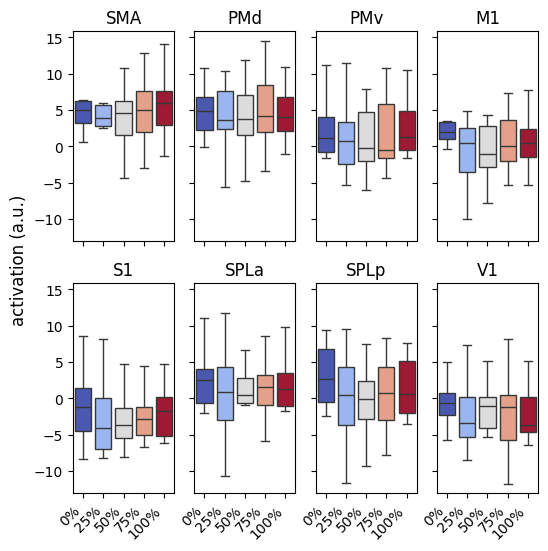

In [9]:
experiment = 'smp2'
snS = [102, 103, 104, 106, 107]
glm = 12
Hem = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']

conditions = ['0%','25%', '50%', '75%', '100%']

df_con = pd.read_csv(os.path.join(gl.baseDir, experiment, 'ROI.con.avg.tsv'), sep='\t')
df_con['condition'] = df_con['condition'].str.replace(" ", "")
df_con['sn'] = df_con['sn'].astype(str)
df_con = df_con[df_con['condition'].isin(conditions)]
df_con = df_con.groupby(['condition', 'roi', 'Hem', 'sn']).mean(numeric_only=True).reset_index()

fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(6, 6), sharey=True, sharex=True)

for r, roi in enumerate(rois):

    row = r // 4
    col = r % 4

    sns.boxplot(df_con[df_con['roi'] == roi],
                ax=axs[row, col],
                y='activity',
                x='condition',
                order=conditions,
                palette=[gl.colour_mapping[cond] for cond in conditions],
                showfliers=False)

    axs[row, col].set_title(roi)
    axs[row, col].set_ylabel('')
    axs[row, col].set_xlabel('')
    axs[row, col].tick_params(axis='x', rotation=45)
    plt.setp(axs[row, col].get_xticklabels(), ha='right')

fig.supylabel('activation (a.u.)')
fig.suptitle(f'Average activity during planning, hemisphere:{L}')

Text(0.5, 0.98, 'Average activity during execution')

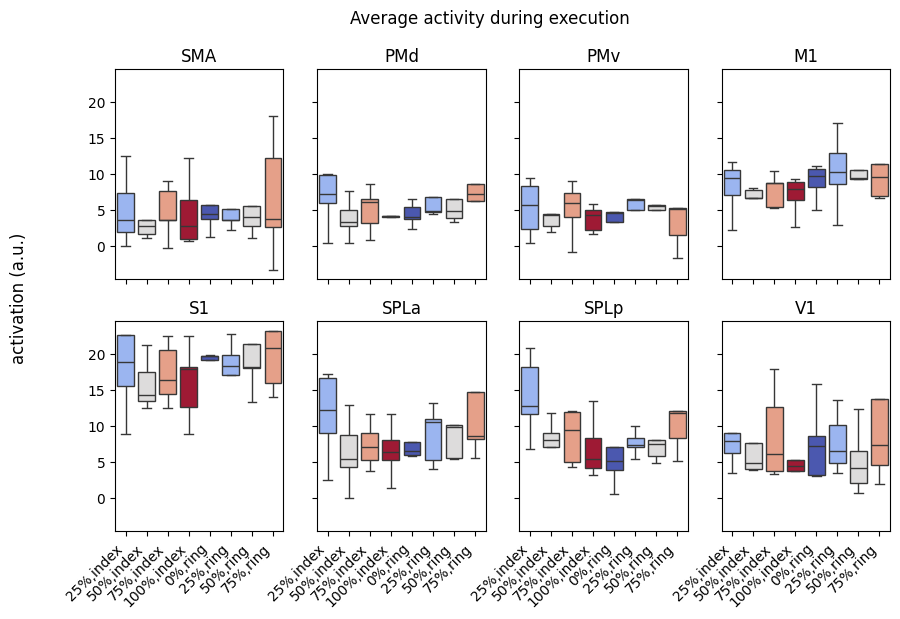

In [8]:
experiment = 'smp2'
snS = [102, 103, 104, 106, 107]
glm = 12
Hem = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']

conditions = ['25%,index', '50%,index', '75%,index', '100%,index',
              '0%,ring', '25%,ring', '50%,ring', '75%,ring']

df_con = pd.read_csv(os.path.join(gl.baseDir, experiment, 'ROI.con.avg.tsv'), sep='\t')
df_con['condition'] = df_con['condition'].str.replace(" ", "")
df_con['sn'] = df_con['sn'].astype(str)
df_con = df_con[df_con['condition'].isin(conditions)]
df_con = df_con.groupby(['condition', 'roi', 'Hem', 'sn']).mean(numeric_only=True).reset_index()

fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(10, 6), sharey=True, sharex=True)

for r, roi in enumerate(rois):

    row = r // 4
    col = r % 4

    sns.boxplot(df_con[(df_con['roi'] == roi) & (df_con['Hem'] == Hem)],
                ax=axs[row, col],
                y='activity',
                x='condition',
                order=conditions,
                palette=[gl.colour_mapping[cond] for cond in conditions],
                showfliers=False)

    axs[row, col].set_title(roi)
    axs[row, col].set_ylabel('')
    axs[row, col].set_xlabel('')
    axs[row, col].tick_params(axis='x', rotation=45)
    plt.setp(axs[row, col].get_xticklabels(), ha='right')

fig.supylabel('activation (a.u.)')
fig.suptitle(f'Average activity during execution, hemisphere:{Hem}')

 # **Cue representation**

## **Planning**

Text(0.5, 0.98, 'Planning, average distances across participants (N=5), hemisphere:L')

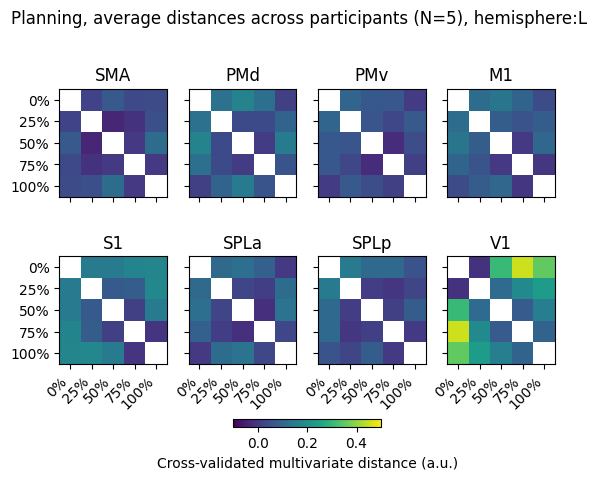

In [8]:
experiment = 'smp2'
Hem = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
vmin, vmax = -.1, .5
snS=[102, 103, 104, 106, 107]
glm = 12
r = 0

fig, axs = plt.subplots(nrows=2, ncols=4, sharex=True, sharey=True)

for r, roi in enumerate(rois):
    
    row = r // 4  
    col = r % 4
    
    rdms = list()
    for sn in snS:
        rdm = rsa.rdm.load_rdm(os.path.join(gl.baseDir, experiment, gl.rdmDir, f'subj{sn}', f'glm{glm}.{Hem}.{roi}.hdf5'))
        rdm = rdm.subset_pattern(by='conds', value=['0%', '25%', '50%', '75%', '100%'])
        rdms.append(rdm)
    
    rdms = rsa.rdm.concat(rdms)
    cax = rsa.vis.show_rdm_panel(
            rdms.mean(), axs[row, col], rdm_descriptor='roi', cmap='viridis', vmin=vmin, vmax=vmax
        )
    axs[row, col].set_xticks(np.arange(len(rdms.pattern_descriptors['conds'])))
    axs[row, col].set_xticklabels(rdms.pattern_descriptors['conds'], rotation=45, ha='right')
    axs[row, col].set_yticks(axs[row, col].get_xticks())
    axs[row, col].set_yticklabels(rdms.pattern_descriptors['conds'])
    axs[row, col].set_title(roi)
        
    r += 1

cbar = fig.colorbar(cax, ax=axs, orientation='horizontal', fraction=.02)
cbar.set_label('Cross-validated multivariate distance (a.u.)')
fig.suptitle(f'Planning, average distances across participants (N={len(snS)}), hemisphere:{Hem}')

## **Execution**

Text(0.5, 0.98, 'Execution, average distances across participants (N=5), hemisphere:L')

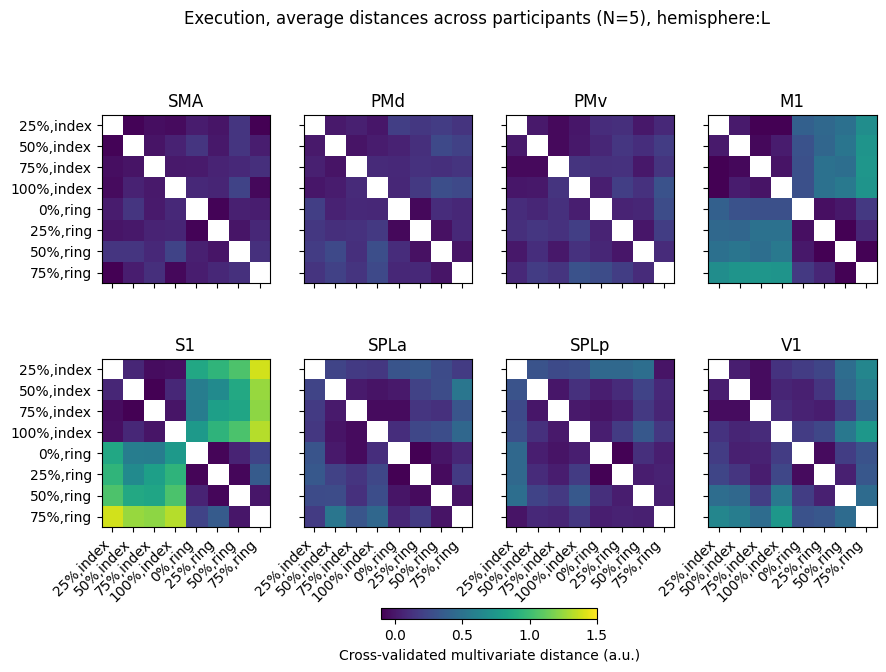

In [9]:
experiment = 'smp2'
Hem = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
vmin, vmax = -.1, 1.5
snS=[102, 103, 104, 106, 107]
glm = 12
r = 0

fig, axs = plt.subplots(nrows=2, ncols=4, sharex=True, sharey=True, figsize=(10, 7))

for r, roi in enumerate(rois):
    
    row = r // 4  
    col = r % 4
    
    rdms = list()
    for sn in snS:
        rdm = rsa.rdm.load_rdm(os.path.join(gl.baseDir, experiment, gl.rdmDir, f'subj{sn}', f'glm{glm}.{Hem}.{roi}.hdf5'))
        rdm = rdm.subset_pattern(by='conds', value=['25%,index', '50%,index', '75%,index', '100%,index',
                                                  '0%,ring', '25%,ring', '50%,ring', '75%,ring',])
        rdms.append(rdm)
    
    rdms = rsa.rdm.concat(rdms)
    cax = rsa.vis.show_rdm_panel(
            rdms.mean(), axs[row, col], rdm_descriptor='roi', cmap='viridis', vmin=vmin, vmax=vmax
        )
    axs[row, col].set_xticks(np.arange(len(rdms.pattern_descriptors['conds'])))
    axs[row, col].set_xticklabels(rdms.pattern_descriptors['conds'], rotation=45, ha='right')
    axs[row, col].set_yticks(axs[row, col].get_xticks())
    axs[row, col].set_yticklabels(rdms.pattern_descriptors['conds'])
    axs[row, col].set_title(roi)
        
    r += 1

cbar = fig.colorbar(cax, ax=axs, orientation='horizontal', fraction=.02)
cbar.set_label('Cross-validated multivariate distance (a.u.)')
fig.suptitle(f'Execution, average distances across participants (N={len(snS)}), hemisphere:{Hem}')


Text(0.5, 0.98, 'Average cosine angle across participants (N=5), hemisphere:L')

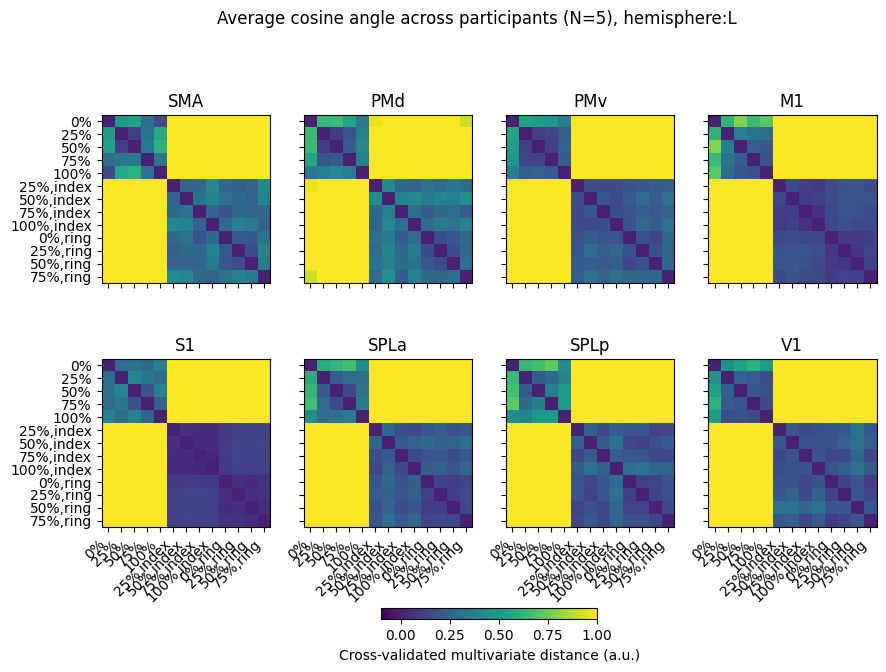

In [13]:
experiment = 'smp2'
Hem = 'L'
rois = ['SMA', 'PMd', 'PMv', 'M1', 'S1', 'SPLa', 'SPLp', 'V1']
vmin, vmax = -.1, 1
snS=[102, 103, 104, 106, 107]
glm = 12
r = 0

fig, axs = plt.subplots(nrows=2, ncols=4, sharex=True, sharey=True, figsize=(10, 7))

for r, roi in enumerate(rois):
    
    row = r // 4  
    col = r % 4
    
    coss = list()
    for sn in snS:
        cos = np.load(os.path.join(gl.baseDir, experiment, gl.cosDir, f'subj{sn}', f'glm{glm}.{Hem}.{roi}.npy'))
        coss.append(cos)
    
    coss = np.stack(coss, axis=0).mean(axis=0)
    cax = axs[row, col].imshow(coss, cmap='viridis', vmin=vmin, vmax=vmax)
    axs[row, col].set_xticks(np.arange(len(list(gl.regressor_mapping.keys()))))
    axs[row, col].set_xticklabels(list(gl.regressor_mapping.keys()), rotation=45, ha='right')
    axs[row, col].set_yticks(axs[row, col].get_xticks())
    axs[row, col].set_yticklabels(list(gl.regressor_mapping.keys()))
    axs[row, col].set_title(roi)
        
    r += 1

cbar = fig.colorbar(cax, ax=axs, orientation='horizontal', fraction=.02)
cbar.set_label('Cross-validated multivariate distance (a.u.)')
fig.suptitle(f'Average cosine angle across participants (N={len(snS)}), hemisphere:{Hem}')